In [1]:
import pandas as pd
import numpy as np

In [6]:
df  = pd.read_csv('../EDA/train.csv',usecols=['Age', 'Fare', 'Survived'])

In [7]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [8]:
df.dropna(inplace=True)

In [9]:
X = df.iloc[:, 1:]

In [10]:
y = df.iloc[:,0]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [12]:
clf = DecisionTreeClassifier()

In [14]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [15]:
accuracy_score(y_test, y_pred)

0.6223776223776224

In [17]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring="accuracy"))

0.6261150234741784

In [19]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy = 'quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode="ordinal", strategy="quantile")

In [20]:
trf = ColumnTransformer([('first',kbin_age,[0]),('second', kbin_fare, [1])])

In [29]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [30]:

clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [35]:
accuracy_score(y_pred2, y_test)

0.6363636363636364

In [37]:
X_trf = trf.fit_transform(X)

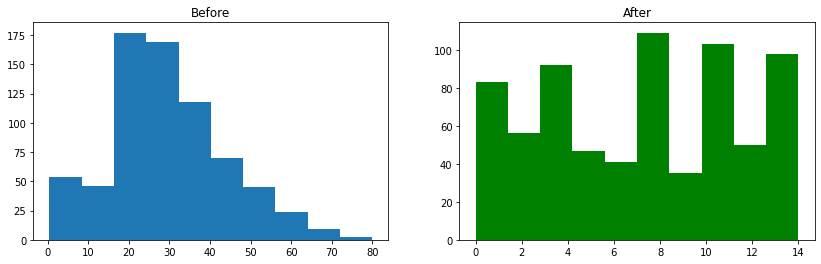

In [43]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X['Age'])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0], color="green")
plt.title("After")

plt.show()

Text(0.5, 1.0, 'After')

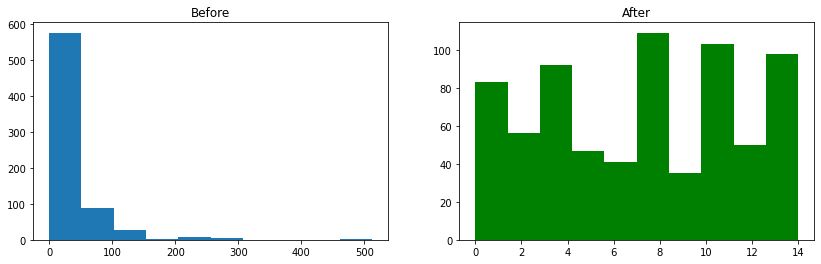

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X["Fare"])
plt.title("Before")

plt.subplot(122)
plt.hist(X_trf[:,0], color = "green")
plt.title("After")